# 04 — SHAP Explainability Analysis
Interpret the LightGBM model using SHAP values.

**Run `02_preprocessing.ipynb` and `03_modeling.ipynb` first** so `data/` and `models/` exist.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import os

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

## Load data and model

In [2]:
X_test        = np.load('data/X_test.npy')
y_test        = np.load('data/y_test.npy')
feature_names = joblib.load('data/feature_names.pkl')
lgb_model     = joblib.load('models/lightgbm.pkl')

X_test_df = pd.DataFrame(X_test, columns=feature_names)
print('X_test:', X_test_df.shape)

X_test: (17948, 28)


## Compute SHAP values (sample of 2,000 test instances)

In [3]:
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test_df), size=min(2000, len(X_test_df)), replace=False)
X_sample = X_test_df.iloc[idx]
y_sample = y_test[idx]

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_sample)
print('SHAP values shape:', shap_values.values.shape)

SHAP values shape: (2000, 28)


## Beeswarm summary plot

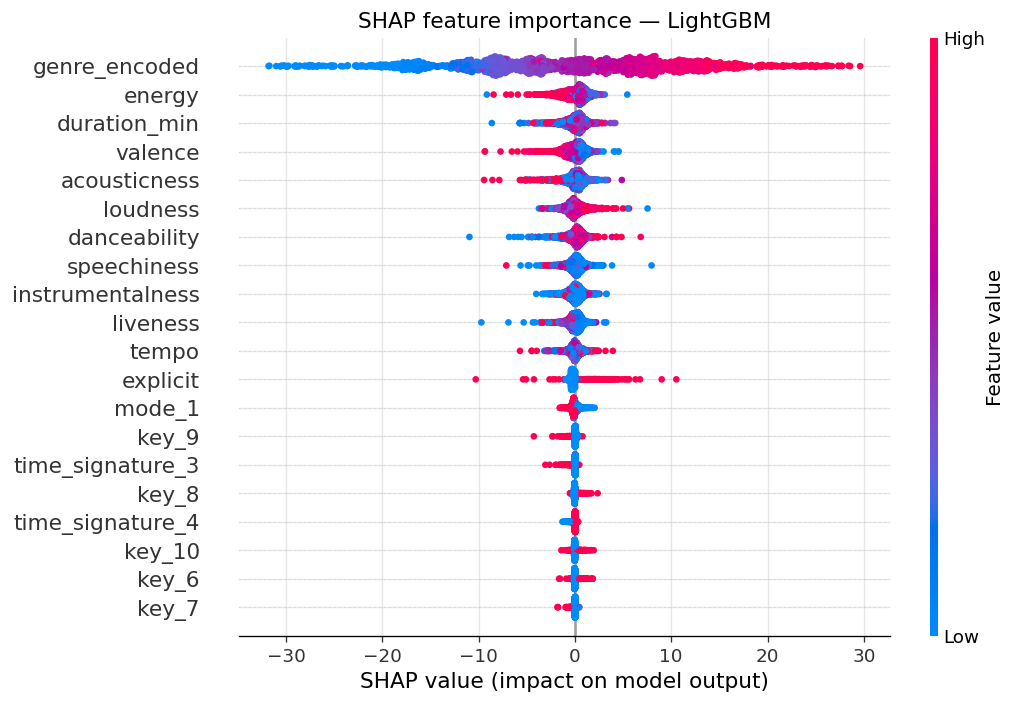

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_values, X_sample, show=False, plot_size=None)
plt.title('SHAP feature importance — LightGBM', fontsize=13)
plt.tight_layout()
plt.savefig('figures/11_shap_beeswarm.png', bbox_inches='tight')
plt.show()

## Bar summary (mean |SHAP|)

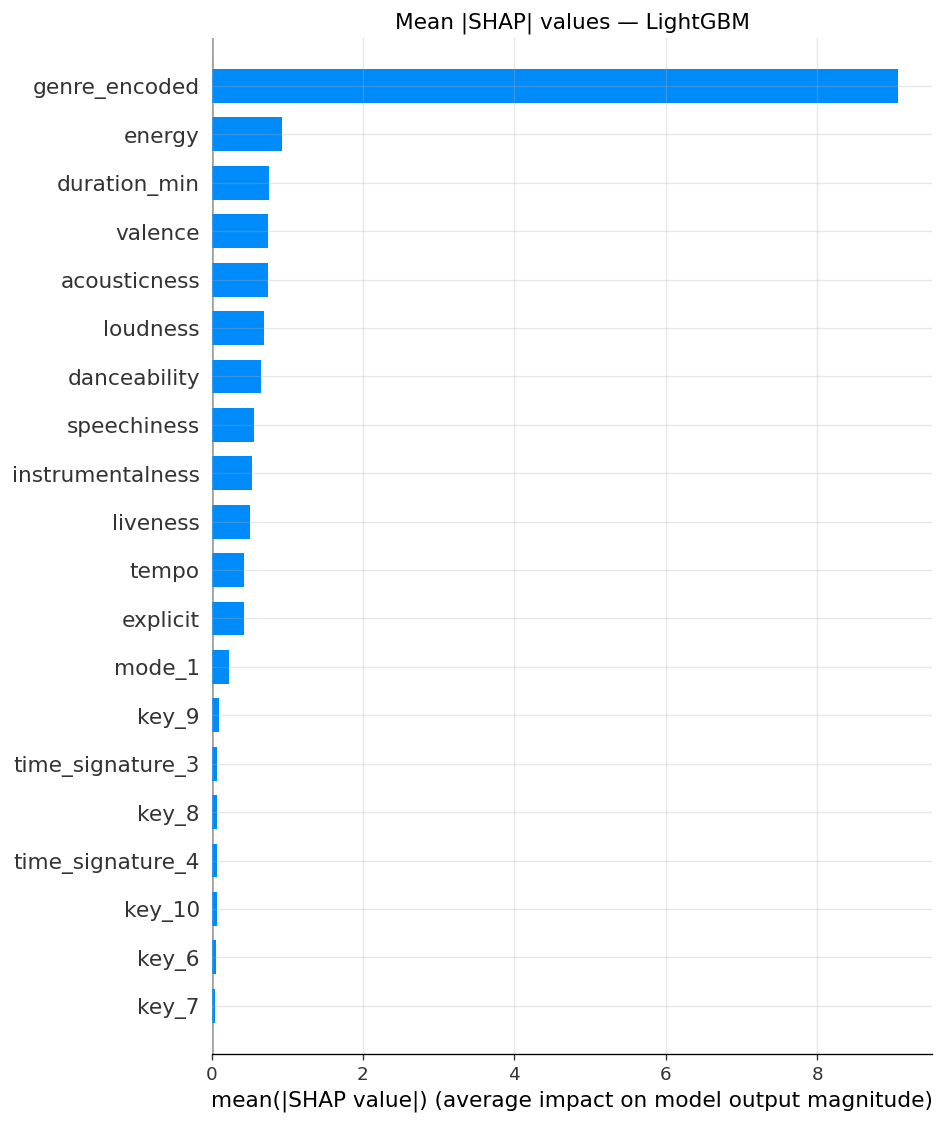

In [5]:
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Mean |SHAP| values — LightGBM', fontsize=13)
plt.tight_layout()
plt.savefig('figures/12_shap_bar.png', bbox_inches='tight')
plt.show()

## Dependence plots for top 3 features

Top 3 features by mean |SHAP|: ['genre_encoded', 'energy', 'duration_min']


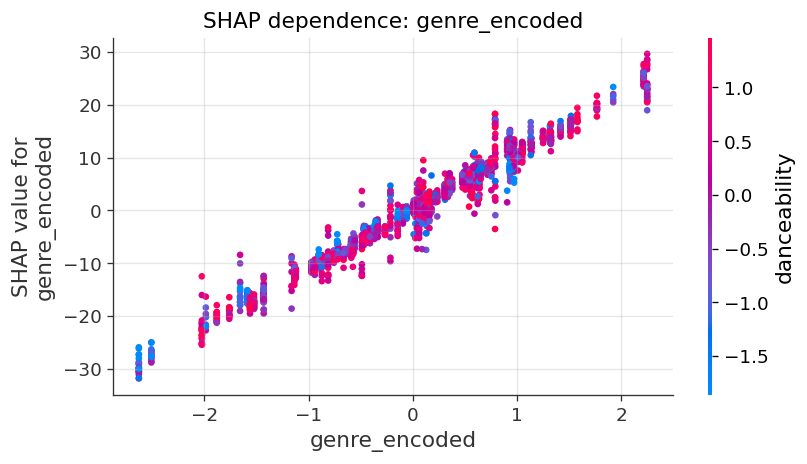

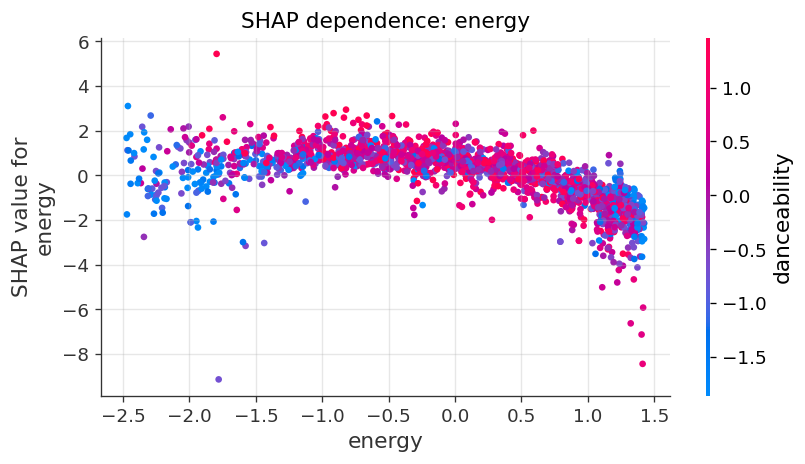

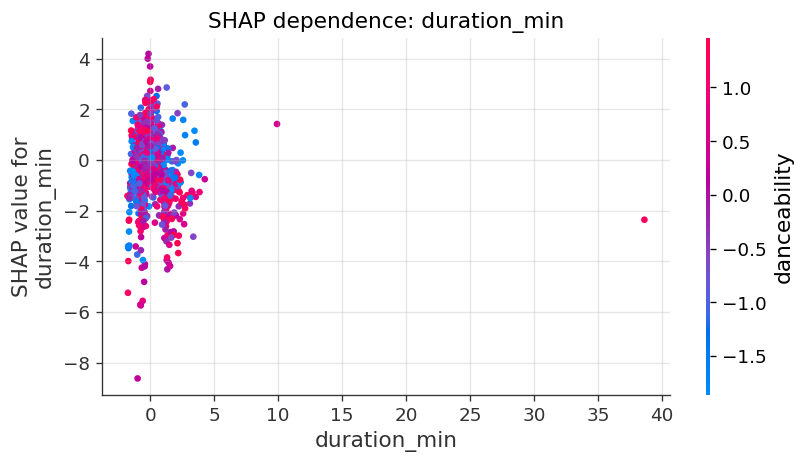

In [6]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = [feature_names[i] for i in top3_idx]
print('Top 3 features by mean |SHAP|:', top3_features)

for feat in top3_features:
    fig, ax = plt.subplots(figsize=(7, 4))
    shap.dependence_plot(feat, shap_values.values, X_sample, show=False, ax=ax)
    ax.set_title(f'SHAP dependence: {feat}', fontsize=13)
    plt.tight_layout()
    safe_name = feat.replace('/', '_')
    plt.savefig(f'figures/13_shap_dep_{safe_name}.png', bbox_inches='tight')
    plt.show()

## Waterfall plot — single prediction example

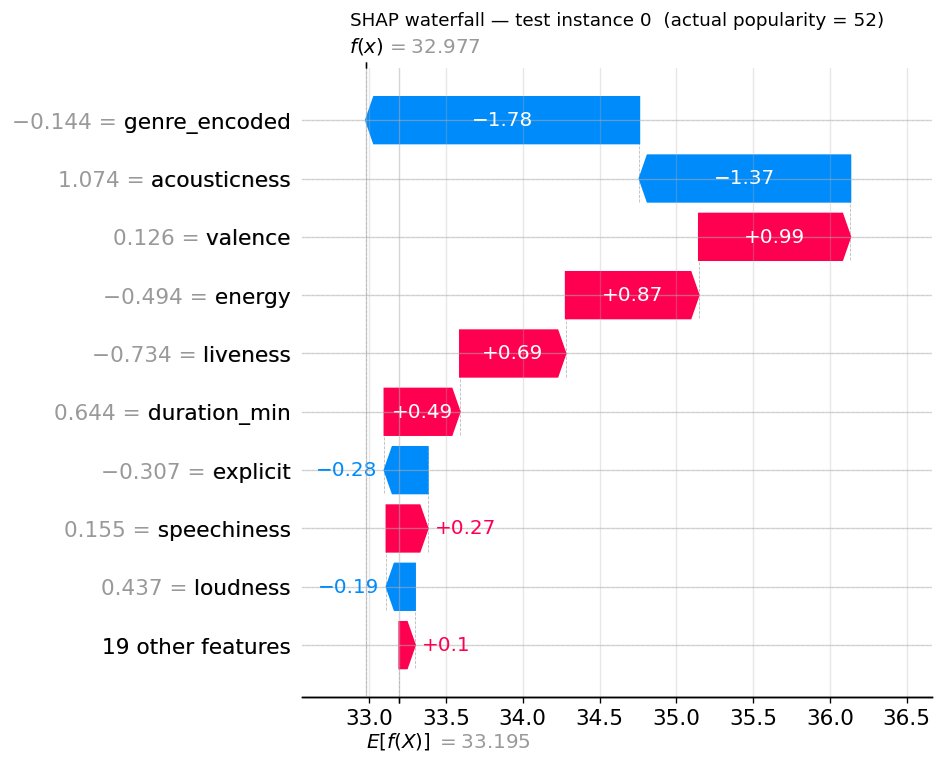

In [7]:
i = 0
shap.waterfall_plot(shap_values[i], show=False)
plt.title(
    f'SHAP waterfall — test instance {i}  '
    f'(actual popularity = {y_sample[i]:.0f})',
    fontsize=11
)
plt.tight_layout()
plt.savefig('figures/14_shap_waterfall.png', bbox_inches='tight')
plt.show()

## Cross-check: SHAP ranking vs LightGBM gain importance

In [8]:
shap_rank = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

gain_rank = pd.Series(
    lgb_model.booster_.feature_importance(importance_type='gain'),
    index=feature_names
).sort_values(ascending=False)

comparison = pd.DataFrame({
    'SHAP rank':   range(1, len(shap_rank) + 1),
    'Gain rank':   [gain_rank.index.get_loc(f) + 1 for f in shap_rank.index],
    'Mean |SHAP|': shap_rank.values.round(3),
    'Gain':        [gain_rank[f] for f in shap_rank.index],
}, index=shap_rank.index)

print('Top 15 features — SHAP vs Gain ranking:')
comparison.head(15)

Top 15 features — SHAP vs Gain ranking:


,SHAP rank,Gain rank,Mean |SHAP|,Gain
genre_encoded,1,1,9.069,1.919022e+08
energy,2,5,0.929,1.657547e+07
duration_min,3,2,0.753,1.899459e+07
valence,4,7,0.746,1.617064e+07
acousticness,5,3,0.746,1.830672e+07
loudness,6,8,0.690,1.591925e+07
danceability,7,4,0.652,1.764362e+07
speechiness,8,6,0.566,1.647922e+07
instrumentalness,9,11,0.530,1.400624e+07
liveness,10,10,0.513,1.492182e+07
